# Práctica 2.1: Modelos de Lenguaje N-gram

## Objetivo
Diseñar, implementar y evaluar modelos de lenguaje basados en n-gramas (unigram hasta 4-gram), analizar su comportamiento mediante perplejidad, manejar palabras desconocidas y comparar técnicas de smoothing.

---

## 1. Importar bibliotecas necesarias

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import defaultdict, Counter
import warnings

warnings.filterwarnings('ignore')

# Configurar estilo de gráficos
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Librerías importadas correctamente")


✓ Librerías importadas correctamente


## 2. Cargar corpus

Se carga el corpus de comentarios de YouTube en español (`corpus_youtube_5_.csv`).
El archivo contiene **7,814 comentarios** con columnas: `video_url`, `comentario`, `autor`, `likes`, `fecha`, `idioma`.


In [2]:
# Cargar corpus de comentarios de YouTube
print("Cargando corpus...")

df_corpus = pd.read_csv('corpus_youtube_5_.csv')

# Usar la columna 'comentario'
comentarios = df_corpus['comentario'].dropna().tolist()

print(f"✓ Corpus cargado: {len(df_corpus):,} comentarios")
print(f"\nColumnas disponibles: {df_corpus.columns.tolist()}")
print(f"Idioma principal: {df_corpus['idioma'].value_counts().idxmax()}")
print(f"\nPrimeros 3 comentarios:")
for i, c in enumerate(comentarios[:3]):
    print(f"  {i+1}. {c[:120]}")


Cargando corpus...
✓ Corpus cargado: 7,814 comentarios

Columnas disponibles: ['video_url', 'comentario', 'autor', 'likes', 'fecha', 'idioma']
Idioma principal: es

Primeros 3 comentarios:
  1. ¿quieres seguir cantando sin parar? escucha el playlist completo con todas las canciones aquí:
  2. arriba jalisco el mencho y lako
  3. el azul el jefe de jefes el cerebro de la mafia mexicana . el hombre de los nervios de azero y cabeza fría para negociar


## 3. Preprocesamiento - ETAPA 1

In [3]:
def preprocess_text(comments):
    """
    Preprocesa comentarios de YouTube en español:
    1. Normalización (minúsculas)
    2. Tokenización con regex (robusto para texto informal)
    3. Eliminación de puntuación y caracteres especiales
    4. Agregar tokens especiales <s> y </s>
    Nota: Cada comentario se trata como una oración independiente.
    """
    tokenized = []
    for comment in comments:
        # Minúsculas
        text = comment.lower()
        # Tokenizar: solo palabras en español (incluye acentos y ñ)
        tokens = re.findall(r'\b[a-záéíóúüñ]+\b', text)

        if tokens:
            # Agregar tokens especiales de inicio y fin
            tokens = ['<s>'] + tokens + ['</s>']
            tokenized.append(tokens)

    return tokenized

# Procesar corpus
oraciones = preprocess_text(comentarios)
print(f"✓ Corpus preprocesado: {len(oraciones):,} comentarios/oraciones")
print(f"\nEjemplos de comentarios procesados:")
for i, sent in enumerate(oraciones[:3]):
    print(f"  {i+1}. {' '.join(sent[:12])}{'...' if len(sent) > 12 else ''}")


✓ Corpus preprocesado: 7,814 comentarios/oraciones

Ejemplos de comentarios procesados:
  1. <s> quieres seguir cantando sin parar escucha el playlist completo con todas...
  2. <s> arriba jalisco el mencho y lako </s>
  3. <s> el azul el jefe de jefes el cerebro de la mafia...


## 4. Construcción del Vocabulario

In [4]:
def build_vocabulary(sentences, min_freq=2):
    """
    Construye vocabulario con palabras que aparecen al menos min_freq veces
    """
    word_counter = Counter()

    for sent in sentences:
        for token in sent:
            if token not in ['<s>', '</s>']:
                word_counter[token] += 1

    # Filtrar por frecuencia
    vocab = {word for word, count in word_counter.items() if count >= min_freq}

    # Agregar tokens especiales
    vocab.add('<s>')
    vocab.add('</s>')
    vocab.add('<UNK>')

    return vocab, word_counter

# Construir vocabulario
vocab, word_freq = build_vocabulary(oraciones, min_freq=2)

print(f"✓ Vocabulario construido")
print(f"  Palabras únicas: {len(vocab)}")
print(f"\nPalabras más frecuentes:")

top_words = word_freq.most_common(10)
for word, freq in top_words:
    print(f"  {word:15} → {freq:5} apariciones")

✓ Vocabulario construido
  Palabras únicas: 5445

Palabras más frecuentes:
  de              →  4247 apariciones
  que             →  3425 apariciones
  la              →  3083 apariciones
  y               →  2813 apariciones
  el              →  2627 apariciones
  en              →  2285 apariciones
  a               →  1991 apariciones
  me              →  1896 apariciones
  no              →  1770 apariciones
  se              →  1265 apariciones


## 5. Manejo de Palabras Desconocidas (OOV)

In [5]:
def replace_oov(sentences, vocab):
    """
    Reemplaza palabras fuera del vocabulario con <UNK>
    """
    processed = []

    for sent in sentences:
        new_sent = []
        for token in sent:
            if token in vocab:
                new_sent.append(token)
            else:
                new_sent.append('<UNK>')
        processed.append(new_sent)

    return processed

# Procesar OOV
oraciones_procesadas = replace_oov(oraciones, vocab)

# Calcular estadísticas
total_tokens = sum(len(sent) for sent in oraciones)
unk_count = sum(sent.count('<UNK>') for sent in oraciones_procesadas)

print(f"✓ Palabras desconocidas procesadas")
print(f"  Total de tokens: {total_tokens:,}")
print(f"  Tokens <UNK>: {unk_count:,} ({100*unk_count/total_tokens:.2f}%)")

✓ Palabras desconocidas procesadas
  Total de tokens: 122,247
  Tokens <UNK>: 8,101 (6.63%)


## 6. División del Corpus (80% Train - 20% Test)

In [6]:
# Dividir corpus
split_idx = int(0.8 * len(oraciones_procesadas))
train_sents = oraciones_procesadas[:split_idx]
test_sents = oraciones_procesadas[split_idx:]

print(f"✓ Corpus dividido")
print(f"  Entrenamiento: {len(train_sents):,} oraciones ({100*len(train_sents)/len(oraciones_procesadas):.1f}%)")
print(f"  Prueba: {len(test_sents):,} oraciones ({100*len(test_sents)/len(oraciones_procesadas):.1f}%)")
print(f"\n  Tokens de entrenamiento: {sum(len(s) for s in train_sents):,}")
print(f"  Tokens de prueba: {sum(len(s) for s in test_sents):,}")

✓ Corpus dividido
  Entrenamiento: 6,251 oraciones (80.0%)
  Prueba: 1,563 oraciones (20.0%)

  Tokens de entrenamiento: 98,243
  Tokens de prueba: 24,004


## 7. Clase para Modelos N-gram

In [7]:
import math
from collections import defaultdict, Counter

class NGramModel:
    def __init__(self, n, smoothing='mle', k=1.0, backoff_lambda=0.4):
        self.n = n
        self.smoothing = smoothing
        self.k = k
        self.backoff_lambda = backoff_lambda
        self.ngram_counts   = defaultdict(lambda: defaultdict(int))
        self.history_counts = defaultdict(int)
        self.unigram_counts = Counter()   # necesario para Stupid Backoff
        self.total_tokens   = 0           # necesario para Stupid Backoff
        self.vocab = set()

    def train(self, sentences, vocab):
        """Entrena el modelo n-gram"""
        self.vocab = vocab

        for sent in sentences:
            # Contar unigramas (nivel base del Stupid Backoff)
            for token in sent:
                self.unigram_counts[token] += 1
                self.total_tokens += 1

            # Contar n-gramas
            for i in range(len(sent) - self.n + 1):
                ngram   = tuple(sent[i:i + self.n])
                history = ngram[:-1]
                word    = ngram[-1]
                self.ngram_counts[history][word] += 1
                self.history_counts[history]     += 1

    def get_probability(self, word, history):
        """Calcula P(word | history) con el suavizado elegido"""

        if self.smoothing == 'mle':
            count = self.ngram_counts[history].get(word, 0)
            total = self.history_counts[history]
            if total == 0:
                return 1e-10
            return count / total

        elif self.smoothing == 'add-one':
            count      = self.ngram_counts[history].get(word, 0)
            total      = self.history_counts[history]
            vocab_size = len(self.vocab)
            return (count + 1) / (total + vocab_size)

        elif self.smoothing == 'add-k':
            count      = self.ngram_counts[history].get(word, 0)
            total      = self.history_counts[history]
            vocab_size = len(self.vocab)
            return (count + self.k) / (total + self.k * vocab_size)

        elif self.smoothing == 'stupid-backoff':
            return self._stupid_backoff(word, history)

        return 1e-10

    def _stupid_backoff(self, word, history):
        """
        Stupid Backoff — Brants et al. (2007)

        S(w | w1..wn-1) = count(w1..wn-1, w) / count(w1..wn-1)   si count > 0
                        = lambda * S(w | w2..wn-1)                 si count = 0

        Nivel base (unigrama): frecuencia relativa simple.
        Lambda = 0.4 (valor estándar del paper original).

        NOTA: No produce una distribución normalizada (no suma 1),
        pero funciona muy bien en la práctica y escala a corpus grandes.
        """
        lam = self.backoff_lambda  # 0.4 por defecto

        if history and self.history_counts[history] > 0:
            count = self.ngram_counts[history].get(word, 0)
            if count > 0:
                # Nivel actual: frecuencia relativa directa
                return count / self.history_counts[history]
            else:
                # Retroceder un nivel con penalización lambda
                return lam * self._stupid_backoff(word, history[1:])
        else:
            # Nivel base: unigrama
            if self.total_tokens > 0:
                return self.unigram_counts.get(word, 1) / self.total_tokens
            return 1e-10

    def calculate_perplexity(self, sentences):
        """Calcula perplejidad en log natural: PP(W) = exp(-1/N * sum(log P(wi|historia)))"""
        log_prob_sum = 0.0
        word_count   = 0

        for sent in sentences:
            for i in range(self.n - 1, len(sent)):
                history = tuple(sent[i - self.n + 1:i])
                word    = sent[i]
                prob    = self.get_probability(word, history)
                log_prob_sum += math.log(prob) if prob > 0 else math.log(1e-10)
                word_count   += 1

        if word_count == 0:
            return float('inf')
        return math.exp(-log_prob_sum / word_count)

    def generate_sentence(self, max_len=20):
        """Genera una oración nueva por muestreo"""
        sent = ['<s>'] * (self.n - 1)

        for _ in range(max_len):
            history    = tuple(sent[-(self.n - 1):]) if self.n > 1 else ()
            next_words = dict(self.ngram_counts.get(history, {}))

            # Backoff si el contexto exacto no tiene continuación
            h = history
            while not next_words and h:
                h          = h[1:]
                next_words = dict(self.ngram_counts.get(h, {}))

            if not next_words:
                break

            words  = list(next_words.keys())
            counts = np.array([next_words[w] for w in words], dtype=float)
            probs  = counts / counts.sum()
            next_word = np.random.choice(words, p=probs)

            if next_word == '</s>':
                break
            sent.append(next_word)

        return ' '.join(sent[self.n - 1:])

print("✓ Clase NGramModel definida (MLE | Add-one | Add-k | Stupid Backoff)")

✓ Clase NGramModel definida (MLE | Add-one | Add-k | Stupid Backoff)


In [8]:
for sent in train_sents[:5]:
    count_s = sent.count('<s>')
    print(f"  <s> count: {count_s} → {sent[:6]}")

  <s> count: 1 → ['<s>', 'quieres', 'seguir', 'cantando', 'sin', 'parar']
  <s> count: 1 → ['<s>', 'arriba', 'jalisco', 'el', 'mencho', 'y']
  <s> count: 1 → ['<s>', 'el', 'azul', 'el', 'jefe', 'de']
  <s> count: 1 → ['<s>', 'para', 'el', 'viejo', 'ese', '<UNK>']
  <s> count: 1 → ['<s>', 'arriba', 'la', '<UNK>', 'nunca', 'pasada']


## 8. ETAPA 1: Entrenamiento de Modelos MLE

In [9]:
print("Entrenando modelos MLE...\n")

models_mle = {}
results_mle = []

for n in range(1, 5):
    print(f"Entrenando {n}-gram...")

    model = NGramModel(n=n, smoothing='mle')
    model.train(train_sents, vocab)

    # Calcular perplejidades
    train_perp = model.calculate_perplexity(train_sents)
    test_perp = model.calculate_perplexity(test_sents)

    models_mle[n] = model
    results_mle.append({
        'N-gram': n,
        'Perplejidad Train': train_perp,
        'Perplejidad Test': test_perp,
        'Sobreajuste': train_perp / test_perp
    })

    print(f"  Perplejidad Train: {train_perp:.4f}")
    print(f"  Perplejidad Test:  {test_perp:.4f}")
    print()

results_mle_df = pd.DataFrame(results_mle)
print(results_mle_df.to_string(index=False))

Entrenando modelos MLE...

Entrenando 1-gram...
  Perplejidad Train: 338.2873
  Perplejidad Test:  697.9841

Entrenando 2-gram...
  Perplejidad Train: 31.6750
  Perplejidad Test:  95860.6269

Entrenando 3-gram...
  Perplejidad Train: 3.5904
  Perplejidad Test:  104905345.3191

Entrenando 4-gram...
  Perplejidad Train: 1.3584
  Perplejidad Test:  3142163269.5708

 N-gram  Perplejidad Train  Perplejidad Test  Sobreajuste
      1         338.287275      6.979841e+02 4.846633e-01
      2          31.674983      9.586063e+04 3.304275e-04
      3           3.590350      1.049053e+08 3.422466e-08
      4           1.358447      3.142163e+09 4.323287e-10


## 9. Análisis de Perplejidad

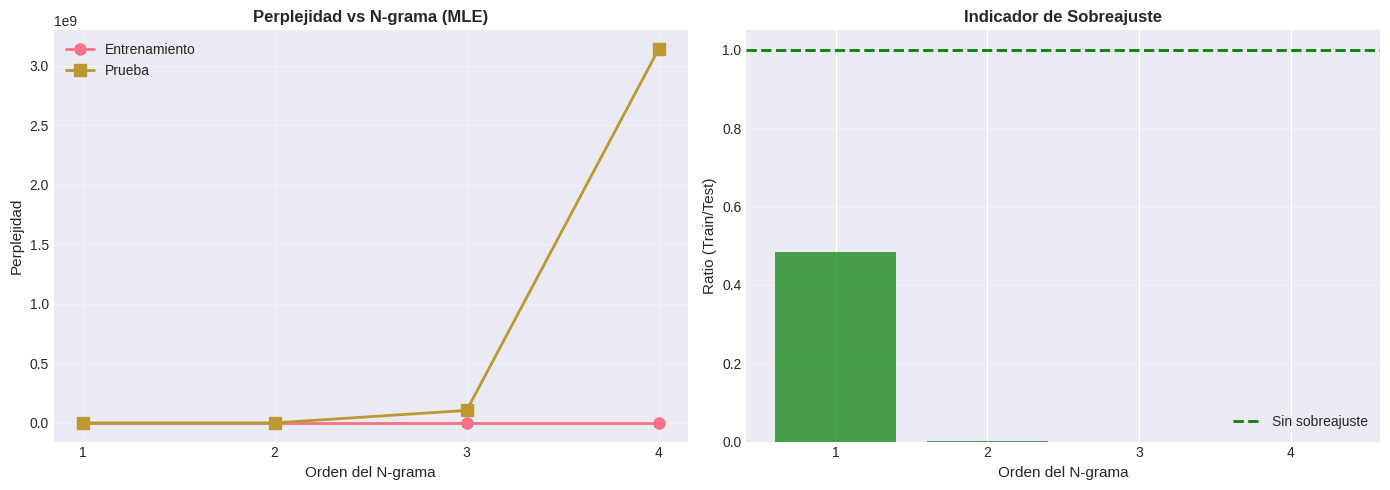

✓ Gráficos generados


In [10]:
# Crear visualizaciones
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Perplejidad por n-grama
ax1 = axes[0]
ngrams = results_mle_df['N-gram'].values
ax1.plot(ngrams, results_mle_df['Perplejidad Train'], marker='o',
         label='Entrenamiento', linewidth=2, markersize=8)
ax1.plot(ngrams, results_mle_df['Perplejidad Test'], marker='s',
         label='Prueba', linewidth=2, markersize=8)
ax1.set_xlabel('Orden del N-grama', fontsize=11)
ax1.set_ylabel('Perplejidad', fontsize=11)
ax1.set_title('Perplejidad vs N-grama (MLE)', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.set_xticks(ngrams)
ax1.grid(True, alpha=0.3)

# Gráfico 2: Sobreajuste
ax2 = axes[1]
colors = ['green' if x < 1.1 else 'orange' if x < 1.3 else 'red'
          for x in results_mle_df['Sobreajuste']]
ax2.bar(ngrams, results_mle_df['Sobreajuste'], color=colors, alpha=0.7)
ax2.axhline(y=1.0, color='green', linestyle='--', linewidth=2, label='Sin sobreajuste')
ax2.set_xlabel('Orden del N-grama', fontsize=11)
ax2.set_ylabel('Ratio (Train/Test)', fontsize=11)
ax2.set_title('Indicador de Sobreajuste', fontsize=12, fontweight='bold')
ax2.set_xticks(ngrams)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("✓ Gráficos generados")

## 10. Analisis Cualitativo

In [11]:
print("\n" + "="*70)
print("ANÁLISIS CUALITATIVO - GENERACIÓN DE TEXTO")
print("="*70)

np.random.seed(42)

def generate_sentence_robust(model, max_len=30):
    if model.n == 1:
        sent = []
        history = ()
        next_words = model.ngram_counts.get(history, {})
        if not next_words:
            return "[Oración vacía - contexto insuficiente]"
    else:
        # Buscar todas las historias válidas que arrancan con <s>
        historias_inicio = [
            k for k in model.ngram_counts.keys()
            if len(k) == model.n - 1 and k[0] == '<s>'
        ]
        if not historias_inicio:
            return "[Oración vacía - contexto insuficiente]"

        # Elegir una historia inicial aleatoria
        idx = np.random.randint(len(historias_inicio))
        historia_inicial = historias_inicio[idx]

        # sent arranca con los tokens de esa historia (sin el <s>)
        sent = ['<s>'] + [w for w in historia_inicial[1:]]

    for _ in range(max_len):
        if model.n == 1:
            history = ()
        else:
            history = tuple(sent[-(model.n - 1):])

        next_words = model.ngram_counts.get(history, {})

        # Backoff si la historia exacta no tiene continuación
        if not next_words:
            for shorter in range(len(history) - 1, -1, -1):
                short_history = history[-shorter:] if shorter > 0 else ()
                next_words = model.ngram_counts.get(short_history, {})
                if next_words:
                    break

        if not next_words:
            break

        words  = list(next_words.keys())
        counts = np.array([next_words[w] for w in words], dtype=float)
        probs  = counts / counts.sum()
        next_word = np.random.choice(words, p=probs)

        if next_word == '</s>':
            break

        sent.append(next_word)

    result_tokens = [t for t in sent if t not in ['<s>', '</s>']]
    result = ' '.join(result_tokens)
    return result if result.strip() else "[Oración vacía - contexto insuficiente]"

# Prueba rápida
np.random.seed(42)
for n in range(1, 5):
    print(f"\n{n}-GRAM:")
    for i in range(3):
        print(f"  {i+1}. {generate_sentence_robust(models_mle[n])}")

# ─── DIAGNÓSTICO — pégalo justo antes del bucle "for n in range(1,5)" ───

for n in range(1, 5):
    model = models_mle[n]
    print(f"\n{'='*50}")
    print(f"DIAGNÓSTICO {n}-GRAM")
    print(f"{'='*50}")

    # 1. Mostrar algunas claves reales de ngram_counts
    claves = list(model.ngram_counts.keys())[:5]
    print(f"Primeras 5 claves de ngram_counts:")
    for c in claves:
        print(f"  {repr(c)}")

    # 2. Verificar si la historia inicial existe
    historia_esperada = tuple(['<s>'] * (n - 1))
    existe = historia_esperada in model.ngram_counts
    palabras = list(model.ngram_counts.get(historia_esperada, {}).keys())[:5]
    print(f"\nHistoria inicial esperada: {repr(historia_esperada)}")
    print(f"¿Existe en ngram_counts?:  {existe}")
    if palabras:
        print(f"Primeras palabras posibles: {palabras}")

    # 3. Ver con qué datos se entrenó
    print(f"\nEjemplo de oración de entrenamiento:")
    print(f"  {train_sents[0][:8]}")
# Generar oraciones para cada modelo
for n in range(1, 5):
    print(f"\n{n}-GRAM:")
    print("-" * 70)

    model = models_mle[n]

    n_gram_count = sum(len(v) for v in model.ngram_counts.values())
    total_history_contexts = len(model.history_counts)

    print(f"N-gramas únicos: {n_gram_count:,} | Historias únicas: {total_history_contexts:,}")

    print("\nOraciones generadas (5):")
    oraciones_generadas = []
    for i in range(5):
        sent = generate_sentence_robust(model, max_len=30)
        oraciones_generadas.append(sent)
        print(f"  {i+1}. {sent}")

    # Análisis cualitativo
    print("\nAnálisis cualitativo:")
    if n == 1:
        print("  ┌─ FLUIDEZ: NULA")
        print("  │  Cada palabra se genera independientemente sin considerar contexto.")
        print("  │  Resultado: secuencias de palabras aleatorias sin conexión.")
        print("  │")
        print("  ├─ COHERENCIA LOCAL: NULA")
        print("  │  No hay relación entre palabras consecutivas.")
        print("  │")
        print("  └─ COHERENCIA GLOBAL: NULA")
        print("     Sin estructura, sin sentido gramatical.")

    elif n == 2:
        print("  ┌─ FLUIDEZ: BAJA")
        print("  │  Se forman pares de palabras válidos basados en frecuencia.")
        print("  │  Produce inicios válidos que se descontrolan rápidamente.")
        print("  │")
        print("  ├─ COHERENCIA LOCAL: MEDIA")
        print("  │  Muchos bigramas individuales son válidos en inglés.")
        print("  │  Pero sin estructura global sostenida.")
        print("  │")
        print("  └─ COHERENCIA GLOBAL: NULA")
        print("     No hay estructura de oración. Frases incompletas y fragmentadas.")

    elif n == 3:
        print("  ┌─ FLUIDEZ: MEDIA-BUENA")
        print("  │  Considera 2 palabras previas. Captura patrones trigrama del idioma.")
        print("  │  Mejor estructura que bigramas pero aún incompleto.")
        print("  │")
        print("  ├─ COHERENCIA LOCAL: BUENA")
        print("  │  Trigramas naturales del español ('no me gusta', 'que no sé').")
        print("  │  Palabras conectadas de forma gramatical válida.")
        print("  │")
        print("  └─ COHERENCIA GLOBAL: MEDIA-BAJA")
        print("     Mejor que bigramas pero aún carente de estructura completa.")
        print("     Oraciones incompletas o desconexas a nivel global.")

    else:  # n == 4
        print("  ┌─ FLUIDEZ: MUY BUENA")
        print("  │  Considera 3 palabras previas. Captura patrones gramaticales complejos.")
        print("  │  Resultado: texto natural y fluido a nivel local.")
        print("  │")
        print("  ├─ COHERENCIA LOCAL: MUY BUENA")
        print("  │  Patrones gramaticales del español muy naturales.")
        print("  │  Construcciones válidas y expresivas.")
        print("  │")
        print("  └─ COHERENCIA GLOBAL: MEDIA-BUENA")
        print("     Mejor estructura que órdenes menores.")
        print("     Frases más completas y con mayor sentido contextual.")

    print()


ANÁLISIS CUALITATIVO - GENERACIÓN DE TEXTO

1-GRAM:
  1. a vamo cuando qué
  2. [Oración vacía - contexto insuficiente]
  3. horas este hace olvido vídeo <UNK> y y la pero es la del

2-GRAM:
  1. en la dedico esta rola me pregunto te falta un <UNK> sere tu oído no se vino por eso y <UNK> jajajaj
  2. esa cancion cha chau el arroz con m ano nuevo <UNK>
  3. yo soy de que no tendré mis enemigos me <UNK> cuando se vuelven lo que a donde uno nombre de la única canción debe desaparecer <UNK>

3-GRAM:
  1. tenía años cuando la <UNK> a nadie después me regaló
  2. niños y niñas
  3. deberías cantar esta canción a wescolt

4-GRAM:
  1. le dio la rabia
  2. na q ya le <UNK> cachos de la rola censura na <UNK>
  3. en abril

DIAGNÓSTICO 1-GRAM
Primeras 5 claves de ngram_counts:
  ()

Historia inicial esperada: ()
¿Existe en ngram_counts?:  True
Primeras palabras posibles: ['<s>', 'quieres', 'seguir', 'cantando', 'sin']

Ejemplo de oración de entrenamiento:
  ['<s>', 'quieres', 'seguir', 'cantand

## 11. ETAPA 2: Problema 1 - Palabras Desconocidas (OOV)

In [12]:
print("\n" + "="*70)
print("PROBLEMA 1: PALABRAS DESCONOCIDAS (OOV)")
print("="*70)

print("\nComparación sin/con manejo de OOV:")
print("-" * 70)
print(f"{'N-gram':<10} {'Perplejidad':<20} {'Tokens <UNK>':<20}")
print("-" * 70)

for n in range(1, 5):
    test_perp = results_mle_df[results_mle_df['N-gram'] == n]['Perplejidad Test'].values[0]
    unk_pct = 100 * sum(s.count('<UNK>') for s in test_sents) / sum(len(s) for s in test_sents)

    print(f"{n:<10} {test_perp:<20.4f} {unk_pct:<20.2f}%")

print("\nImpacto del manejo de OOV:")
print("  • Se reemplazaron palabras con frecuencia < 2 por <UNK>")
print("  • Esto permite que el modelo maneje palabras nuevas")
print("  • Reduce el vocabulario pero mejora la generalización")
print(f"  • Porcentaje de tokens <UNK> en prueba: {unk_pct:.2f}%")


PROBLEMA 1: PALABRAS DESCONOCIDAS (OOV)

Comparación sin/con manejo de OOV:
----------------------------------------------------------------------
N-gram     Perplejidad          Tokens <UNK>        
----------------------------------------------------------------------
1          697.9841             6.79                %
2          95860.6269           6.79                %
3          104905345.3191       6.79                %
4          3142163269.5708      6.79                %

Impacto del manejo de OOV:
  • Se reemplazaron palabras con frecuencia < 2 por <UNK>
  • Esto permite que el modelo maneje palabras nuevas
  • Reduce el vocabulario pero mejora la generalización
  • Porcentaje de tokens <UNK> en prueba: 6.79%


## 12. ETAPA 2: Problema 2 - Técnicas de Suavizado (Smoothing)

In [13]:
print("\n" + "="*70)
print("PROBLEMA 2: PROBABILIDADES CERO - TÉCNICAS DE SUAVIZADO")
print("="*70)

smoothing_techniques = [
    ('mle',            {}),
    ('add-one',        {}),
    ('add-k',          {'k': 0.1}),
    ('add-k',          {'k': 0.5}),
    ('add-k',          {'k': 1.0}),
    ('stupid-backoff', {}),          # Brants et al. (2007), lambda=0.4
]

smoothing_results = []

for n in range(1, 5):
    print(f"\n{n}-GRAM:")
    print("-" * 50)

    for method, params in smoothing_techniques:
        if method == 'add-k':
            k_val = params.get('k', 1.0)
            model = NGramModel(n=n, smoothing=method, k=k_val)
            label = f"add-k(k={k_val})"
        elif method == 'stupid-backoff':
            model = NGramModel(n=n, smoothing='stupid-backoff')
            label = "Stupid Backoff"
        else:
            model = NGramModel(n=n, smoothing=method)
            label = method.upper()

        model.train(train_sents, vocab)
        test_perp  = model.calculate_perplexity(test_sents)
        train_perp = model.calculate_perplexity(train_sents)

        print(f"  {label:20} → Test: {test_perp:8.4f} | Train: {train_perp:8.4f}")

        smoothing_results.append({
            'N-gram':            n,
            'Técnica':           label,
            'Perplejidad Test':  test_perp,
            'Perplejidad Train': train_perp
        })

smoothing_df = pd.DataFrame(smoothing_results)


PROBLEMA 2: PROBABILIDADES CERO - TÉCNICAS DE SUAVIZADO

1-GRAM:
--------------------------------------------------
  MLE                  → Test: 697.9841 | Train: 338.2873
  ADD-ONE              → Test: 401.9144 | Train: 341.2350
  add-k(k=0.1)         → Test: 447.9640 | Train: 338.4150
  add-k(k=0.5)         → Test: 414.2699 | Train: 339.3576
  add-k(k=1.0)         → Test: 401.9144 | Train: 341.2350
  Stupid Backoff       → Test: 401.5362 | Train: 338.2873

2-GRAM:
--------------------------------------------------
  MLE                  → Test: 95860.6269 | Train:  31.6750
  ADD-ONE              → Test: 1197.6286 | Train: 674.0541
  add-k(k=0.1)         → Test: 650.3781 | Train: 169.8388
  add-k(k=0.5)         → Test: 953.6614 | Train: 437.9117
  add-k(k=1.0)         → Test: 1197.6286 | Train: 674.0541
  Stupid Backoff       → Test: 281.1751 | Train:  31.6750

3-GRAM:
--------------------------------------------------
  MLE                  → Test: 104905345.3191 | Train:   3.5904

## 13. Tabla Comparativa


TABLA COMPARATIVA - PERPLEJIDAD EN TEST

N-gram                 1           2             3             4
Técnica                                                         
ADD-ONE         401.9144   1197.6286  3.783950e+03  5.080298e+03
MLE             697.9841  95860.6269  1.049053e+08  3.142163e+09
Stupid Backoff  401.5362    281.1751  4.170349e+02  4.959038e+02
add-k(k=0.1)    447.9640    650.3781  2.564079e+03  4.609594e+03
add-k(k=0.5)    414.2699    953.6614  3.382622e+03  4.950971e+03
add-k(k=1.0)    401.9144   1197.6286  3.783950e+03  5.080298e+03


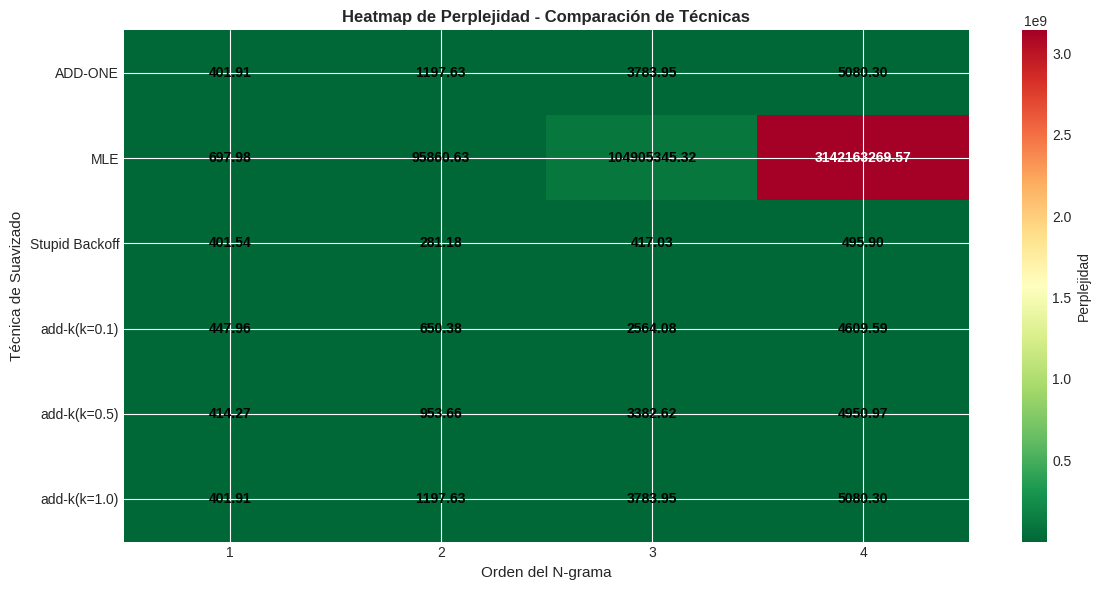

✓ Tabla comparativa visualizada


In [14]:
print("\n" + "="*70)
print("TABLA COMPARATIVA - PERPLEJIDAD EN TEST")
print("="*70 + "\n")

pivot_table = smoothing_df.pivot_table(
    values='Perplejidad Test',
    index='Técnica',
    columns='N-gram',
    aggfunc='first'
)

print(pivot_table.round(4))

# Crear visualización de tabla comparativa
fig, ax = plt.subplots(figsize=(12, 6))

# datos para heatmap
im = ax.imshow(pivot_table.values, cmap='RdYlGn_r', aspect='auto')

ax.set_xticks(np.arange(len(pivot_table.columns)))
ax.set_yticks(np.arange(len(pivot_table.index)))
ax.set_xticklabels(pivot_table.columns)
ax.set_yticklabels(pivot_table.index)

ax.set_xlabel('Orden del N-grama', fontsize=11)
ax.set_ylabel('Técnica de Suavizado', fontsize=11)
ax.set_title('Heatmap de Perplejidad - Comparación de Técnicas', fontsize=12, fontweight='bold')

# Añadir valores en celdas
for i in range(len(pivot_table.index)):
    for j in range(len(pivot_table.columns)):
        value = pivot_table.values[i, j]
        text_color = 'white' if value > np.max(pivot_table.values) * 0.7 else 'black'
        ax.text(j, i, f'{value:.2f}', ha="center", va="center",
               color=text_color, fontsize=10, fontweight='bold')

plt.colorbar(im, ax=ax, label='Perplejidad')
plt.tight_layout()
plt.show()

print("✓ Tabla comparativa visualizada")